# Constrained vs. unconstrained decoding for English → ASL gloss — figures and diagnostics

Companion notebook to `report.tex`, loads `results/*.json` and produces what the report does not carry as text


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('results')
FIG = Path('figures'); FIG.mkdir(exist_ok=True)  # PDFs included by report.tex

SYSTEM_ORDER = ['zero-shot', 'few-shot', 'bart', 'llama-qlora']
SYSTEM_LABEL = {'zero-shot': 'Zero-shot 3B', 'few-shot': 'Few-shot 3B',
                'bart': 'FT BART', 'llama-qlora': 'QLoRA 3B'}
COND_ORDER = ['unc', 'con', 'copy']
COND_LABEL = {'unc': 'Unconstrained', 'con': 'Constrained', 'copy': 'Constrained + copy'}

def parse_run(path):
    with open(path, encoding='utf-8') as f:
        d = json.load(f)
    name = d['run'].replace('_v3', '')
    if name.startswith('trainfree_shots0'): system = 'zero-shot'
    elif name.startswith('trainfree_shots5'): system = 'few-shot'
    else: system = name.rsplit('_', 1)[0]
    cond = name.rsplit('_', 1)[1]
    row = {'system': system, 'condition': cond, 'grammar': d['grammar_version'], **d['metrics'],
           'tok_s': d['speed']['tokens_per_s'], 's_per_ex': d['speed']['s_per_example']}
    return row, d['examples']

rows, examples = [], {}
for p in sorted(RESULTS.glob('*.json')):
    if '_limit' in p.name: continue  # smoke tests
    row, exs = parse_run(p)
    rows.append(row)
    examples[(row['system'], row['condition'], row['grammar'])] = exs

runs = pd.DataFrame(rows)
runs['system'] = pd.Categorical(runs['system'], SYSTEM_ORDER, ordered=True)
runs['condition'] = pd.Categorical(runs['condition'], COND_ORDER, ordered=True)
runs = runs.sort_values(['system', 'condition', 'grammar']).reset_index(drop=True)

# main grid = v3 (report Table "Main grid"); unc runs are stamped v3 too
df = runs[runs.grammar == 'v3'].reset_index(drop=True)
print(f"{len(runs)} runs loaded, {len(df)} in the v3 main grid (n={df['n'].iloc[0]} examples each)")
df[['system', 'condition', 'bleu', 'chrf', 'rouge_l', 'exact_match',
    'token_validity', 'sequence_validity', 'tok_s']]


16 runs loaded, 12 in the v3 main grid (n=1000 examples each)


,system,condition,bleu,chrf,rouge_l,exact_match,token_validity,sequence_validity,tok_s
0,zero-shot,unc,7.56,47.65,48.79,0.4,49.02,3.3,22.508331
1,zero-shot,con,7.73,36.35,37.19,0.5,99.65,95.0,20.392158
2,zero-shot,copy,8.32,37.29,37.88,0.6,99.70,95.9,12.865257
3,few-shot,unc,31.03,73.67,73.27,1.2,75.76,5.7,14.227022
4,few-shot,con,31.96,66.77,65.96,1.8,99.98,99.7,17.519803
5,few-shot,copy,32.26,67.61,66.34,1.7,99.98,99.7,18.641222
6,bart,unc,76.68,93.26,95.57,44.5,90.23,48.6,1477.722259
7,bart,con,73.24,85.90,89.50,42.8,100.00,100.0,110.126223
8,bart,copy,74.05,86.29,89.93,44.5,100.00,100.0,94.632416
9,llama-qlora,unc,98.08,99.28,99.15,92.0,99.03,89.8,61.451679


## Deltas vs. unconstrained (per system)

In [2]:
base = df[df.condition == 'unc'].set_index('system')
deltas = []
for cond in ['con', 'copy']:
    sub = df[df.condition == cond].set_index('system')
    for sys_ in sub.index:
        d = {'system': SYSTEM_LABEL.get(sys_, sys_), 'condition': COND_LABEL[cond]}
        for m in ['bleu', 'chrf', 'rouge_l', 'exact_match', 'sequence_validity']:
            d[f'\u0394{m}'] = round(sub.loc[sys_, m] - base.loc[sys_, m], 2)
        d['slowdown \u00d7'] = round(base.loc[sys_, 'tok_s'] / sub.loc[sys_, 'tok_s'], 1)
        deltas.append(d)
pd.DataFrame(deltas)

,system,condition,Δbleu,Δchrf,Δrouge_l,Δexact_match,Δsequence_validity,slowdown ×
0,Zero-shot 3B,Constrained,0.17,-11.30,-11.60,0.1,91.7,1.1
1,Few-shot 3B,Constrained,0.93,-6.90,-7.31,0.6,94.0,0.8
2,FT BART,Constrained,-3.44,-7.36,-6.07,-1.7,51.4,13.4
3,QLoRA 3B,Constrained,-1.40,-0.64,-0.72,-4.1,10.2,1.3
4,Zero-shot 3B,Constrained + copy,0.76,-10.36,-10.91,0.2,92.6,1.7
5,Few-shot 3B,Constrained + copy,1.23,-6.06,-6.93,0.5,94.0,0.8
6,FT BART,Constrained + copy,-2.63,-6.97,-5.64,0.0,51.4,15.6
7,QLoRA 3B,Constrained + copy,-0.04,-0.01,0.03,0.2,10.2,1.4


## Figure: quality and validity across systems and conditions

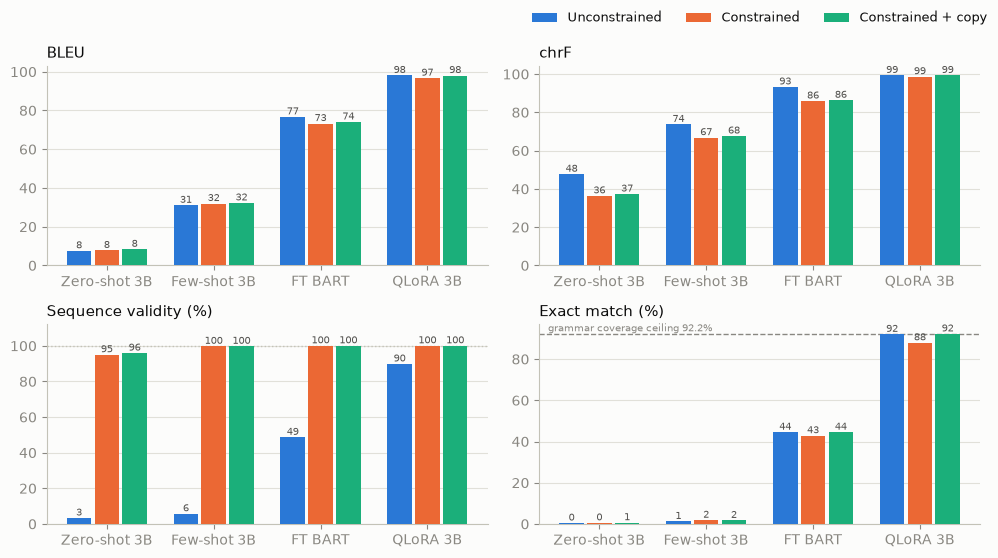

In [3]:
# Validated categorical palette (dataviz reference instance, light mode, fixed order)
COND_COLOR = {'unc': '#2a78d6', 'con': '#eb6834', 'copy': '#1baf7a'}
INK, INK2, MUTED, GRID, BASE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': BASE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

def grouped_bar(ax, metric, title, ylim=None):
    systems = [s for s in SYSTEM_ORDER if s in set(df['system'])]
    conds = [c for c in COND_ORDER if c in set(df['condition'])]
    w = 0.26
    for j, c in enumerate(conds):
        vals, xs = [], []
        for i, s in enumerate(systems):
            sel = df[(df.system == s) & (df.condition == c)]
            if len(sel):
                xs.append(i + (j - (len(conds) - 1) / 2) * w)
                vals.append(sel[metric].iloc[0])
        ax.bar(xs, vals, width=w - 0.03, color=COND_COLOR[c],
               label=COND_LABEL[c], zorder=3)
        for x, v in zip(xs, vals):
            ax.text(x, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7.5, color=INK2)
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels([SYSTEM_LABEL[s] for s in systems])
    ax.set_title(title, loc='left', fontsize=11, color=INK)
    ax.grid(axis='x', visible=False)
    if ylim: ax.set_ylim(*ylim)

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6))
grouped_bar(axes[0, 0], 'bleu', 'BLEU')
grouped_bar(axes[0, 1], 'chrf', 'chrF')
grouped_bar(axes[1, 0], 'sequence_validity', 'Sequence validity (%)', ylim=(0, 112))
axes[1, 0].axhline(100, color=BASE, lw=1, ls=':')
grouped_bar(axes[1, 1], 'exact_match', 'Exact match (%)')
axes[1, 1].axhline(92.2, color=MUTED, lw=1, ls='--')
axes[1, 1].text(0.02, 93.5, 'grammar coverage ceiling 92.2%', fontsize=7.5, color=MUTED,
                transform=axes[1, 1].get_yaxis_transform())
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / 'grid.pdf', bbox_inches='tight')
plt.show()

## Figure: decoding throughput (log scale)

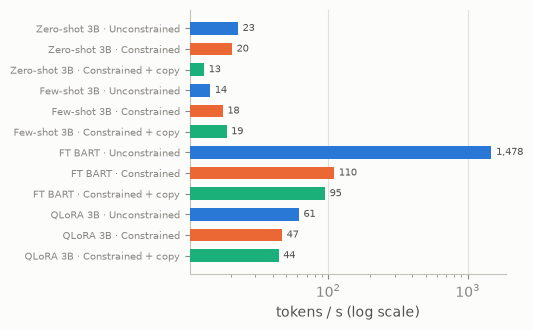

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
sub = df.dropna(subset=['tok_s']).copy()
sub = sub.sort_values(['system', 'condition'])
ys = range(len(sub))
colors = [COND_COLOR[c] for c in sub['condition']]
ax.barh(list(ys), sub['tok_s'], color=colors, height=0.62, zorder=3)
for y, v in zip(ys, sub['tok_s']):
    ax.text(v * 1.08, y, f'{v:,.0f}', va='center', fontsize=7, color=INK2)
ax.set_yticks(list(ys))
ax.set_yticklabels([f"{SYSTEM_LABEL[s]} \u00b7 {COND_LABEL[c]}" for s, c in zip(sub['system'], sub['condition'])], fontsize=7.5)
ax.set_xscale('log')
ax.set_xlabel('tokens / s (log scale)')
ax.grid(axis='y', visible=False)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG / 'speed.pdf', bbox_inches='tight')
plt.show()

## Grammar coverage on the eval subset

Recomputes the eval-subset columns of the report's coverage table (exact-match ceiling and residual reference-token OOV per grammar × condition) and the breakdown of the v2-OOV reference tokens by what would legalize them. Grammar design and the reasoning behind the ceiling are in the report (*Grammars* / *Grammar coverage*); the validity definition is the same `token_valid` the metrics use.


In [5]:
import sys
sys.path.insert(0, 'src')
from glosstrans.data import load_split, load_vocab  # noqa: E402
from glosstrans.grammar import build_ebnf, copy_candidates  # noqa: E402
from glosstrans.metrics import norm, token_valid  # noqa: E402

vocab = set(load_vocab())
eval_set = load_split('eval_subset')
ref_toks = [norm(ex['gloss']).split() for ex in eval_set]
extras_per_ex = [frozenset(copy_candidates(ex['text'], vocab)) for ex in eval_set]

print('EBNF (v3 shown; v2 = same without the DESC- alternative):')
for line in build_ebnf(sorted(vocab)).splitlines():
    print(' ', line if len(line) <= 100 else line[:97] + ' ...')

def v1_ok(t, ex=frozenset()):  # every train token as a literal, no number rule
    return t in vocab or t in ex

def v2_ok(t, ex=frozenset()):
    return token_valid(t, vocab, ex, version='v2')

def v3_ok(t, ex=frozenset()):
    return token_valid(t, vocab, ex, version='v3')

no_extras = [frozenset()] * len(ref_toks)
total_toks = sum(len(t) for t in ref_toks)
ceil_rows = []
for label, ok, extras in [('v1 plain', v1_ok, no_extras), ('v2 plain', v2_ok, no_extras), ('v2 + copy', v2_ok, extras_per_ex),
                          ('v3 plain', v3_ok, no_extras), ('v3 + copy', v3_ok, extras_per_ex)]:
    accepted = sum(all(ok(t, e) for t in toks) for toks, e in zip(ref_toks, extras))
    oov = sum(sum(not ok(t, e) for t in toks) for toks, e in zip(ref_toks, extras))
    ceil_rows.append({'grammar': label, 'exact-match ceiling (%)': round(100 * accepted / len(ref_toks), 1),
                      'residual ref token OOV (%)': round(100 * oov / total_toks, 2)})

cats = {'copyable from source': 0, 'DESC- + legal stem': 0, 'irreducible': 0}
for toks, ex in zip(ref_toks, extras_per_ex):
    for t in toks:
        if v2_ok(t):
            continue
        if t in ex:
            cats['copyable from source'] += 1
        elif t.startswith('DESC-') and (t[5:] in vocab or t[5:] in ex):
            cats['DESC- + legal stem'] += 1
        else:
            cats['irreducible'] += 1
n_oov = sum(cats.values())
print()
print(f'{n_oov} v2-OOV reference tokens: '
      + ', '.join(f'{k} {100 * v / n_oov:.1f}%' for k, v in cats.items()))
pd.DataFrame(ceil_rows)


EBNF (v3 shown; v2 = same without the DESC- alternative):
  root ::= " "? gloss (" " gloss)*
  gloss ::= number | word | "DESC-" word
  number ::= [0-9]+ (("." | ",") [0-9]+)*
  word ::= "!" | "%" | "&" | "+" | "," | "-LRB-" | "-RRB-" | "." | "0US" | "1400LET" | "148SO" | "1 ...

97 v2-OOV reference tokens: copyable from source 51.5%, DESC- + legal stem 19.6%, irreducible 28.9%


,grammar,exact-match ceiling (%),residual ref token OOV (%)
0,v1 plain,91.8,0.84
1,v2 plain,92.2,0.78
2,v2 + copy,95.9,0.38
3,v3 plain,92.2,0.78
4,v3 + copy,97.7,0.23


## Figure: coverage ceiling by grammar version, and what the missing tokens are


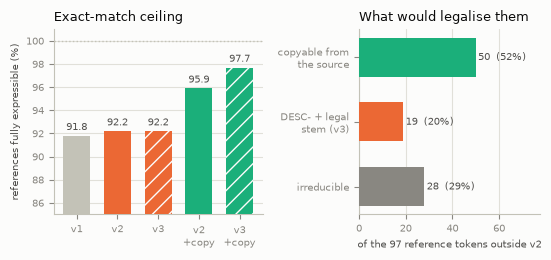

In [6]:
ceil = pd.DataFrame(ceil_rows).set_index('grammar')['exact-match ceiling (%)']
order_g = ['v1 plain', 'v2 plain', 'v3 plain', 'v2 + copy', 'v3 + copy']
bar_color = {'v1 plain': BASE, 'v2 plain': COND_COLOR['con'], 'v3 plain': COND_COLOR['con'],
             'v2 + copy': COND_COLOR['copy'], 'v3 + copy': COND_COLOR['copy']}
cat_color = {'copyable from source': COND_COLOR['copy'], 'DESC- + legal stem': COND_COLOR['con'], 'irreducible': MUTED}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(5.6, 2.7), gridspec_kw={'width_ratios': [3, 2.6]})
xs = range(len(order_g))
axL.bar(xs, [ceil[g] for g in order_g], color=[bar_color[g] for g in order_g], width=0.66, zorder=3,
        hatch=['', '', '//', '', '//'], edgecolor='#fcfcfb', linewidth=0)
for x, g in zip(xs, order_g):
    axL.text(x, ceil[g] + 0.3, f'{ceil[g]:.1f}', ha='center', va='bottom', fontsize=7, color=INK2)
axL.axhline(100, color=BASE, lw=1, ls=':')
axL.set_xticks(list(xs))
axL.set_xticklabels(['v1', 'v2', 'v3', 'v2\n+copy', 'v3\n+copy'], fontsize=7.5)
axL.set_ylim(85, 101)
axL.set_ylabel('references fully expressible (%)', fontsize=7.5)
axL.tick_params(axis='y', labelsize=7)
axL.grid(axis='x', visible=False)
axL.set_title('Exact-match ceiling', loc='left', fontsize=9)

labels = ['copyable from\nthe source', 'DESC- + legal\nstem (v3)', 'irreducible']
vals = list(cats.values())
axR.barh(range(3), vals, color=[cat_color[k] for k in cats], height=0.6, zorder=3)
for y, v in enumerate(vals):
    axR.text(v + 1, y, f'{v}  ({100 * v / n_oov:.0f}%)', va='center', fontsize=7, color=INK2)
axR.set_yticks(range(3))
axR.set_yticklabels(labels, fontsize=7)
axR.invert_yaxis()
axR.set_xlim(0, max(vals) * 1.55)
axR.set_xlabel(f'of the {n_oov} reference tokens outside v2', fontsize=7.5)
axR.tick_params(axis='x', labelsize=7)
axR.grid(axis='y', visible=False)
axR.set_title('What would legalise them', loc='left', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'ceiling.pdf', bbox_inches='tight')
plt.show()


## Figure: exact match vs. the coverage ceilings (fine-tuned systems, v2 vs. v3)

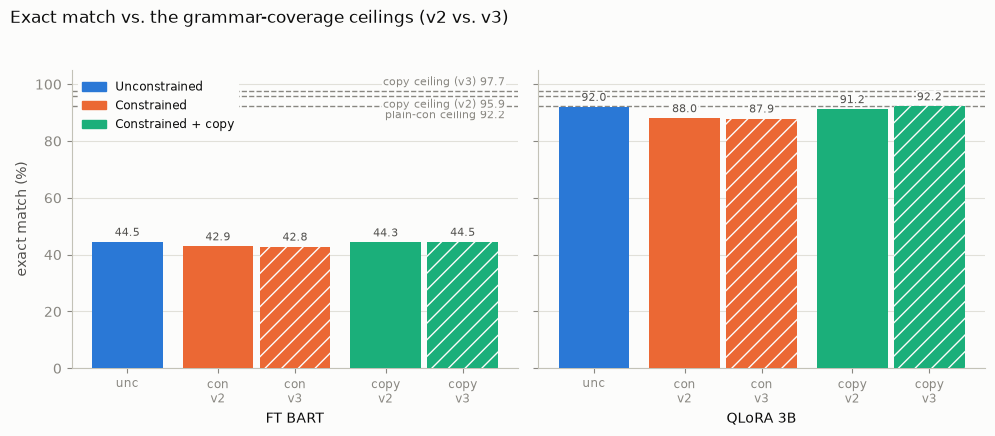

In [7]:
from matplotlib.patches import Patch

def em(system, cond, grammar='v3'):
    sel = runs[(runs.system == system) & (runs.condition == cond) & (runs.grammar == grammar)]
    return float(sel['exact_match'].iloc[0])

order = ['unc', 'con v2', 'con v3', 'copy v2', 'copy v3']
SURFACE = '#fcfcfb'
XPOS = {'unc': 0.0, 'con v2': 1.0, 'con v3': 1.85, 'copy v2': 2.85, 'copy v3': 3.7}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, s, panel in [(axL, 'bart', 'FT BART'), (axR, 'llama-qlora', 'QLoRA 3B')]:
    for var in order:
        cond, *g = var.split()
        v = em(s, cond, g[0] if g else 'v3')
        ax.bar(XPOS[var], v, width=0.78, color=COND_COLOR[cond], zorder=3,
               hatch='//' if var.endswith('v3') else None, edgecolor=SURFACE, linewidth=0)
        ax.text(XPOS[var], v + 1.2, f'{v:.1f}', ha='center', va='bottom', fontsize=8, color=INK2,
                zorder=5, bbox=dict(facecolor=SURFACE, edgecolor='none', pad=0.5))
    for y in (92.2, 95.9, 97.7):
        ax.axhline(y, color=MUTED, lw=1, ls='--', zorder=2)
    ax.set_xticks(list(XPOS.values()))
    ax.set_xticklabels(['unc', 'con\nv2', 'con\nv3', 'copy\nv2', 'copy\nv3'], fontsize=8.5)
    ax.set_xlabel(panel, fontsize=10, color=INK)
    ax.set_ylim(0, 105)
    ax.grid(axis='x', visible=False)

# ceiling labels live in the empty upper half of the BART panel
for y, lbl, va in [(92.2, 'plain-con ceiling 92.2', 'top'),
                   (95.9, 'copy ceiling (v2) 95.9', 'top'),
                   (97.7, 'copy ceiling (v3) 97.7', 'bottom')]:
    axL.text(0.97, y + (1.0 if va == 'bottom' else -1.0), lbl, ha='right', va=va,
             fontsize=8, color=MUTED, transform=axL.get_yaxis_transform(), zorder=5,
             bbox=dict(facecolor=SURFACE, edgecolor='none', pad=0.5))

axL.set_ylabel('exact match (%)')
handles = [Patch(color=COND_COLOR['unc'], label='Unconstrained'),
           Patch(color=COND_COLOR['con'], label='Constrained'),
           Patch(color=COND_COLOR['copy'], label='Constrained + copy')]
axL.legend(handles=handles, loc='upper left', fontsize=8.5, ncol=1,
           frameon=True, facecolor=SURFACE, edgecolor='none', framealpha=1)
fig.suptitle('Exact match vs. the grammar-coverage ceilings (v2 vs. v3)', x=0.01, ha='left', fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
